# **模块**: 单变量统计过程监控
## **课程**: 经典控制图的局限性
### *主题*:  自相关信号下Shewhart控制图的高误报率

In [1]:
# 导入所需包
import numpy as np
import matplotlib.pyplot as plt
# 中文显示设置
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False


> ##### 生成自相关信号以训练Shewhart控制图

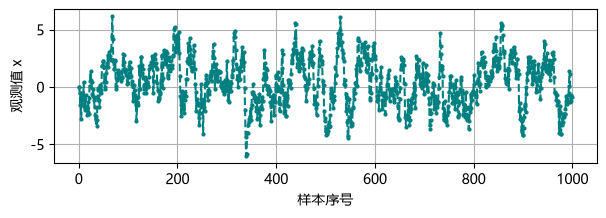

In [2]:
# 生成自相关NOC数据
np.random.seed(1)
N = 1000
e1 = np.random.normal(loc=0, scale=1, size=N)

x_train = np.zeros((N,))
for k in range(2,N):
    x_train[k] = 0.9*x_train[k-1] + e1[k]

plt.figure(figsize=(7,2))
plt.plot(x_train,'--', marker='o', markersize=2, color='teal')
plt.xlabel('样本序号'), plt.ylabel('观测值 x')
plt.grid()
plt.show()


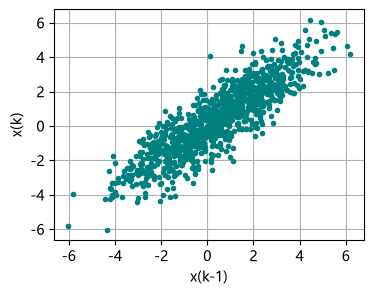

In [3]:
# 绘制xk与xk-1对比
plt.figure(figsize=(4,3))
plt.plot(x_train[0:-1], x_train[1:], '.', color='teal')
plt.xlabel('x(k-1)')
plt.ylabel('x(k)')
plt.grid()
plt.show()

> ##### 将使用上述生成的数据估计Shewhart控制图参数：信号的均值(mu)和标准差(sigma)

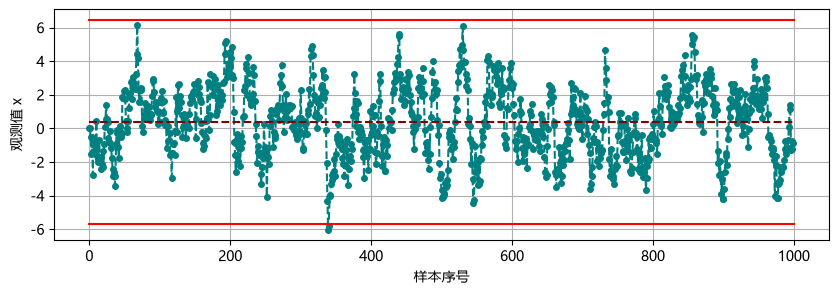

In [4]:
# 估计Shewhart模型参数并绘制控制图
mu, sigma = np.mean(x_train), np.std(x_train)
UCL, LCL = mu + 3*sigma, mu - 3*sigma

plt.figure(figsize=(10,3))
plt.plot(x_train,'--',marker='o', markersize=4, color='teal')
plt.plot([0,N], [UCL,UCL], color='red')
plt.plot([0,N], [LCL,LCL], color='red')
plt.plot([0,N], [mu,mu], '--', color='maroon')
plt.xlabel('样本序号'), plt.ylabel('观测值 x')
plt.grid()
plt.show()

> ##### 生成另一段自相关信号以测试Shewhart控制图性能

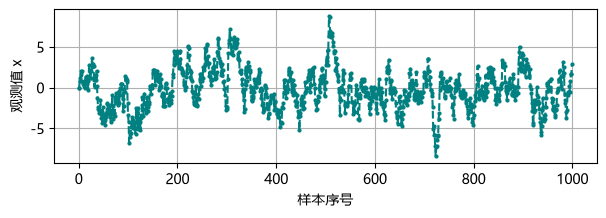

In [5]:
#%% generate test data
np.random.seed(100)
e2 = np.random.normal(loc=0, scale=1, size=N)

x_test = np.zeros((N,))
for k in range(2,N):
    x_test[k] = 0.9*x_test[k-1] + e2[k]

# 故障数据的控制图
plt.figure(figsize=(7,2))
plt.plot(x_test,'--', marker='o', markersize=2, color='teal')
plt.xlabel('样本序号'), plt.ylabel('观测值 x')
plt.grid()
plt.show()

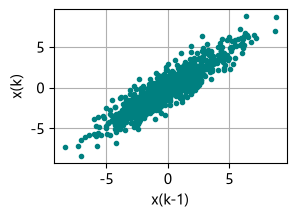

In [6]:
# 绘制xk与xk-1对比
plt.figure(figsize=(3,2))
plt.plot(x_test[0:-1], x_test[1:], '.', color='teal')
plt.xlabel('x(k-1)')
plt.ylabel('x(k)')
plt.grid()
plt.show()

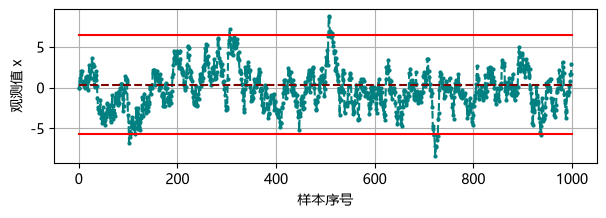

In [7]:
# 绘制控制图
plt.figure(figsize=(7,2))
plt.plot(x_test,'--',marker='o', markersize=2, color='teal')
plt.plot([0,N], [UCL,UCL], color='red')
plt.plot([0,N], [LCL,LCL], color='red')
plt.plot([0,N], [mu,mu], '--', color='maroon')
plt.xlabel('样本序号'), plt.ylabel('观测值 x')
plt.grid()
plt.show()

In [8]:
out_of_control_flags = np.logical_or((x_test<LCL), (x_test>UCL))
N_out_of_control_predictions = np.sum(out_of_control_flags)
FAR = 100*N_out_of_control_predictions/N

print(f'NOC 样本误报率 FAR = {FAR}%')

NOC 样本误报率 FAR = 1.8%
